In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/revenue_ready.csv", parse_dates=["InvoiceDate"])
df.shape

C:\Users\SERIK\AppData\Local\Temp\ipykernel_9620\2508294785.py:4: DtypeWarning: Columns (0: Invoice) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/processed/revenue_ready.csv", parse_dates=["InvoiceDate"])


(1006362, 12)

In [2]:
total_revenue = df["Revenue"].sum()
print(f"Total revenue (Dec 2009 – Dec 2011): £{total_revenue:,.2f}")

Total revenue (Dec 2009 – Dec 2011): £19,700,580.55


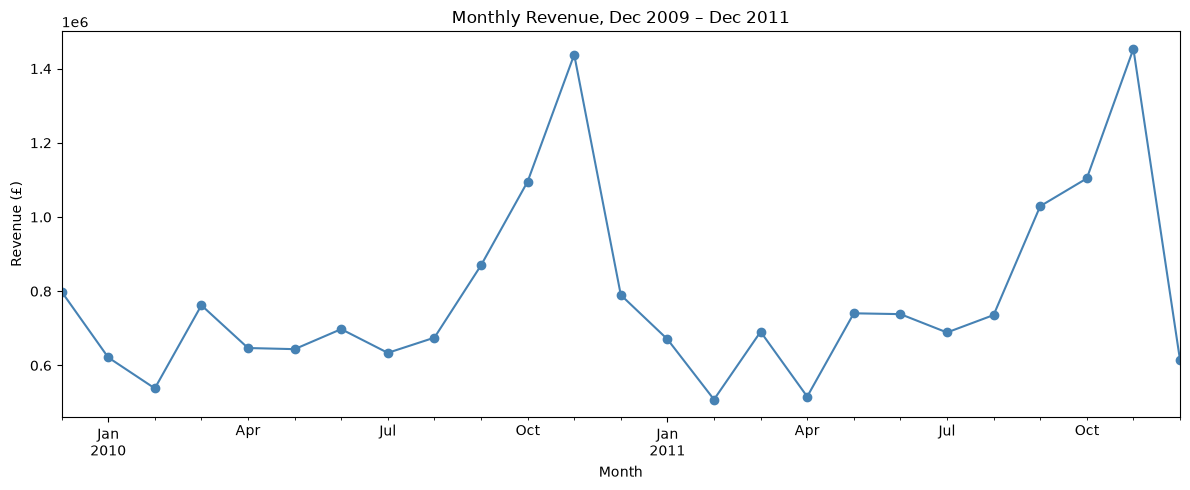

In [3]:
df["YearMonth"] = df["InvoiceDate"].dt.to_period("M")
monthly_revenue = df.groupby("YearMonth")["Revenue"].sum()

fig, ax = plt.subplots(figsize=(12, 5))
monthly_revenue.plot(ax=ax, marker="o", color="steelblue")
ax.set_title("Monthly Revenue, Dec 2009 – Dec 2011")
ax.set_xlabel("Month")
ax.set_ylabel("Revenue (£)")
plt.tight_layout()
plt.savefig("../visuals/monthly_revenue_trend.png", dpi=150)
plt.show()

In [4]:
top_by_revenue = (
    df.groupby(["StockCode", "Description"])["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_by_units = (
    df.groupby(["StockCode", "Description"])["Quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print("Top 10 products by REVENUE:")
print(top_by_revenue)
print("\nTop 10 products by UNITS SOLD:")
print(top_by_units)

Top 10 products by REVENUE:
StockCode  Description                        
22423      REGENCY CAKESTAND 3 TIER               330590.32
85123A     WHITE HANGING HEART T-LIGHT HOLDER     257546.20
23843      PAPER CRAFT , LITTLE BIRDIE            168469.60
47566      PARTY BUNTING                          148318.28
85099B     JUMBO BAG RED RETROSPOT                145961.83
84879      ASSORTED COLOUR BIRD ORNAMENT          129324.49
22086      PAPER CHAIN KIT 50'S CHRISTMAS         117760.29
23166      MEDIUM CERAMIC TOP STORAGE JAR          81700.92
79321      CHILLI LIGHTS                           80540.88
84347      ROTATING SILVER ANGELS T-LIGHT HLDR     71300.40
Name: Revenue, dtype: float64

Top 10 products by UNITS SOLD:
StockCode  Description                       
84077      WORLD WAR 2 GLIDERS ASSTD DESIGNS     106250
85123A     WHITE HANGING HEART T-LIGHT HOLDER     94147
23843      PAPER CRAFT , LITTLE BIRDIE            80995
84879      ASSORTED COLOUR BIRD ORNAMENT         

In [5]:
df[df["InvoiceDate"].dt.to_period("M") == "2011-12"]["InvoiceDate"].dt.day.max()

np.int32(9)

# Day 3 — Revenue, Trends & Product Performance

- **Total revenue** (Dec 2009 - Dec 2011, excluding cancellations/non-products/stock
  adjustments): £[fill in]

- **Monthly trend**: revenue is not flat across the year — a clear seasonal pattern
  emerges. Both 2010 and 2011 show a build-up through September and October, peaking
  in **November** (the highest month in both years), followed by a sharp drop in
  December. Note: December 2011 in this dataset only runs through the 9th of the
  month, so part of that year's December drop is a data-cutoff artifact rather than
  a genuine business trend — worth checking whether the same dip holds for the
  complete December 2009 data before treating it as a confirmed pattern.

- **Seasonality**: the November peak is consistent with a wholesale gift retailer —
  business customers likely place their bulk pre-Christmas stocking orders in
  October/November rather than in December itself, which would explain both the
  build-up and the apparent drop-off once retailers have already stocked their shelves.

- **Top products by revenue vs. units sold**: the two rankings differ substantially.
  The single highest-selling product by units, "WORLD WAR 2 GLIDERS ASSTD DESIGNS,"
  doesn't appear in the top products by revenue at all — suggesting it's a low
  unit-price item sold in very high volume rather than a high-value product. There is
  some overlap, though: "PAPER CRAFT, LITTLE BIRDIE" ranks third on both lists,
  indicating it performs consistently well on both volume and revenue.

In [9]:
import os
print("Current working directory:", os.getcwd())
print("File exists after save:", os.path.exists("../visuals/seasonal_revenue.png"))
print(os.listdir("../visuals"))

Current working directory: C:\Users\SERIK\OneDrive\Desktop\Ecommerce-sales-analysis\notebooks
File exists after save: True
['monthly_revenue_trend.png', 'seasonal_revenue.png']


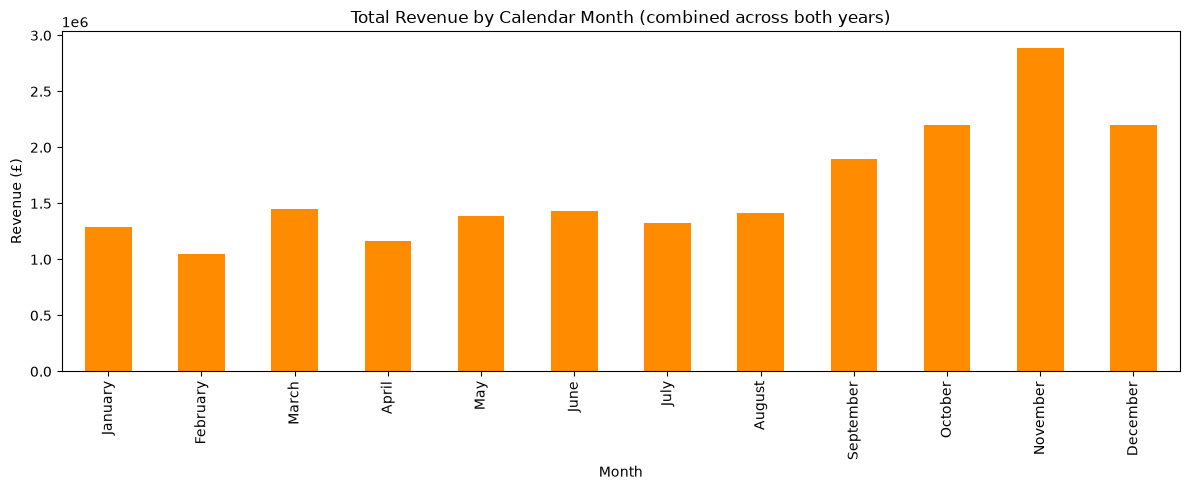

In [8]:
month_order = ["January", "February", "March", "April", "May", "June",
               "July", "August", "September", "October", "November", "December"]

df["MonthName"] = df["InvoiceDate"].dt.month_name()
seasonal_revenue = df.groupby("MonthName")["Revenue"].sum().reindex(month_order)

fig, ax = plt.subplots(figsize=(12, 5))
seasonal_revenue.plot(kind="bar", ax=ax, color="darkorange")
ax.set_title("Total Revenue by Calendar Month (combined across both years)")
ax.set_xlabel("Month")
ax.set_ylabel("Revenue (£)")
plt.tight_layout()
plt.savefig("../visuals/seasonal_revenue.png", dpi=150)
plt.show()